In [2]:
# Cell 1: Setup
import findspark
findspark.init()

from pyspark.sql import SparkSession, functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

spark = SparkSession.builder \
    .appName("Arabic-AI-Detection-Modeling") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f" Spark {spark.version}")

26/05/19 07:13:31 WARN Utils: Your hostname, localhost.localdomain resolves to a loopback address: 127.0.0.1; using 192.168.1.26 instead (on interface enp0s3)
26/05/19 07:13:31 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/19 07:13:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/19 07:13:33 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/05/19 07:13:33 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


 Spark 3.5.8


In [3]:
# Cell 2: Load features
HDFS_FEATURES_ALL = "hdfs://localhost:9000/user/hadoop/arabic-ai-detection/features_all.parquet"
df = spark.read.parquet(HDFS_FEATURES_ALL)

print(f"Rows: {df.count()}")
print(f"Columns: {df.columns}")
print("\nClass balance:")
df.groupBy("label").count().show()

Rows: 41940
Columns: ['text', 'label', 'source', 'generation_method', 'text_clean', 'char_count', 'word_count', 'f_diacritics', 'f_colons', 'f_particles', 'f_first_person', 'f_embed_variance', 'tfidf_features', 'w2v_features']

Class balance:


+-----+-----+
|label|count|
+-----+-----+
|    1|33552|
|    0| 8388|
+-----+-----+



In [4]:
# Cell 3: Stratified split 


df_human = df.filter(F.col("label") == 0)
df_ai = df.filter(F.col("label") == 1)


train_h, val_h, test_h = df_human.randomSplit([0.70, 0.15, 0.15], seed=42)
train_a, val_a, test_a = df_ai.randomSplit([0.70, 0.15, 0.15], seed=42)

train_df = train_h.union(train_a)
val_df = val_h.union(val_a)
test_df = test_h.union(test_a)


train_df = train_df.cache()
val_df = val_df.cache()
test_df = test_df.cache()

print("Stratified split done\n")
print(f"  Train: {train_df.count():>6} ({train_df.filter(F.col('label')==0).count()} H / {train_df.filter(F.col('label')==1).count()} AI)")
print(f"  Val:   {val_df.count():>6} ({val_df.filter(F.col('label')==0).count()} H / {val_df.filter(F.col('label')==1).count()} AI)")
print(f"  Test:  {test_df.count():>6} ({test_df.filter(F.col('label')==0).count()} H / {test_df.filter(F.col('label')==1).count()} AI)")

Stratified split done



26/05/19 07:13:46 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors
                                                                                

  Train:  29625 (5946 H / 23679 AI)


  Val:     6156 (1212 H / 4944 AI)


  Test:    6159 (1230 H / 4929 AI)


In [5]:
# Cell 4: Build the feature vector


STYLO_COLS = ["f_diacritics", "f_colons", "f_particles", "f_first_person",
              "f_embed_variance", "char_count", "word_count"]


assembler_w2v = VectorAssembler(
    inputCols=STYLO_COLS + ["w2v_features"],
    outputCol="features_raw"
)


scaler = StandardScaler(inputCol="features_raw", outputCol="features",
                       withMean=False, withStd=True)

print(" Feature assembler ready: stylometric (7) + Word2Vec (100) = 107 dims")

 Feature assembler ready: stylometric (7) + Word2Vec (100) = 107 dims


Logistic Regression validation results:
  Accuracy: 0.9496
  F1:       0.9492
  ROC-AUC:  0.9858


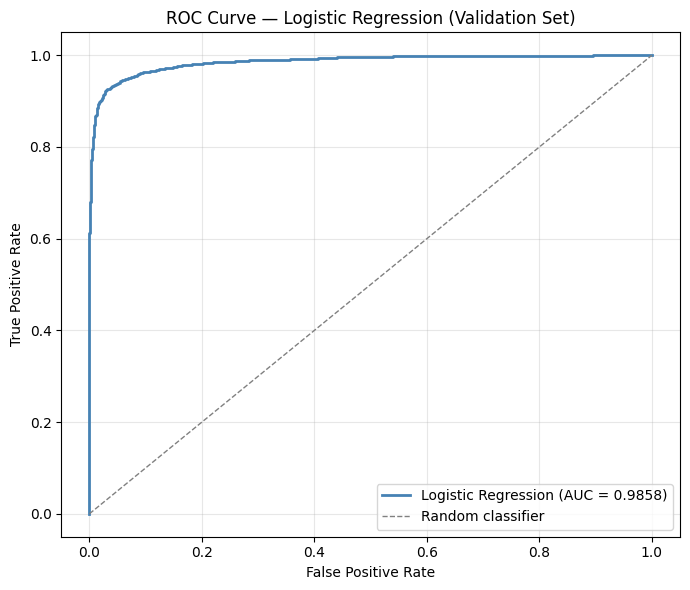

Saved figure to reports/figures/roc_lr.png


In [18]:
#cell 5 Logistic Regression baseline
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=50,
    regParam=0.01,
    elasticNetParam=0.0
)

pipeline_lr = Pipeline(stages=[assembler_w2v, scaler, lr])
model_lr = pipeline_lr.fit(train_df)
val_pred_lr = model_lr.transform(val_df)

evaluator_auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

auc_lr = evaluator_auc.evaluate(val_pred_lr)

print("Logistic Regression validation results:")
print(f"  Accuracy: {evaluator_acc.evaluate(val_pred_lr):.4f}")
print(f"  F1:       {evaluator_f1.evaluate(val_pred_lr):.4f}")
print(f"  ROC-AUC:  {auc_lr:.4f}")


import matplotlib.pyplot as plt
import os
from sklearn.metrics import roc_curve

os.makedirs("../reports/figures", exist_ok=True)


probs_pdf = val_pred_lr.select("label", "probability").toPandas()
y_true = probs_pdf["label"].values
y_score = probs_pdf["probability"].apply(lambda v: float(v[1])).values

fpr, tpr, _ = roc_curve(y_true, y_score)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"Logistic Regression (AUC = {auc_lr:.4f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random classifier")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Logistic Regression (Validation Set)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/roc_lr.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure to reports/figures/roc_lr.png")

26/05/19 07:27:09 WARN DAGScheduler: Broadcasting large task binary with size 1164.2 KiB
26/05/19 07:27:10 WARN DAGScheduler: Broadcasting large task binary with size 2024.8 KiB
26/05/19 07:27:12 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
26/05/19 07:27:15 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
26/05/19 07:27:18 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


Random Forest validation results:


26/05/19 07:27:18 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


  Accuracy: 0.9639


26/05/19 07:27:19 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


  F1:       0.9637
  ROC-AUC:  0.9909


26/05/19 07:27:19 WARN DAGScheduler: Broadcasting large task binary with size 3.6 MiB


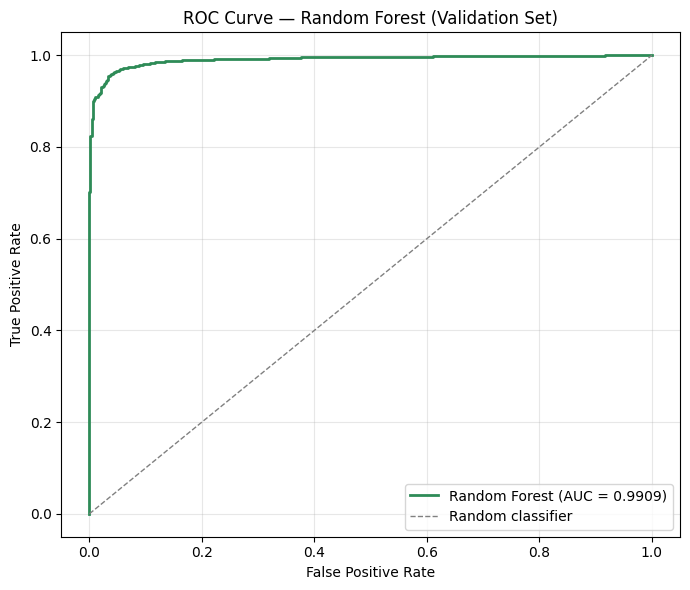

Saved figure to reports/figures/roc_rf.png


In [19]:
#cell 6 Random Forest
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=50,
    maxDepth=10,
    seed=42
)

pipeline_rf = Pipeline(stages=[assembler_w2v, scaler, rf])
model_rf = pipeline_rf.fit(train_df)
val_pred_rf = model_rf.transform(val_df)

auc_rf = evaluator_auc.evaluate(val_pred_rf)

print("Random Forest validation results:")
print(f"  Accuracy: {evaluator_acc.evaluate(val_pred_rf):.4f}")
print(f"  F1:       {evaluator_f1.evaluate(val_pred_rf):.4f}")
print(f"  ROC-AUC:  {auc_rf:.4f}")


import matplotlib.pyplot as plt
import os
from sklearn.metrics import roc_curve

os.makedirs("../reports/figures", exist_ok=True)

probs_pdf = val_pred_rf.select("label", "probability").toPandas()
y_true = probs_pdf["label"].values
y_score = probs_pdf["probability"].apply(lambda v: float(v[1])).values

fpr, tpr, _ = roc_curve(y_true, y_score)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="seagreen", linewidth=2, label=f"Random Forest (AUC = {auc_rf:.4f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random classifier")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Random Forest (Validation Set)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/roc_rf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure to reports/figures/roc_rf.png")

Gradient Boosted Trees validation results:
  Accuracy: 0.9573
  F1:       0.9573
  ROC-AUC:  0.9882


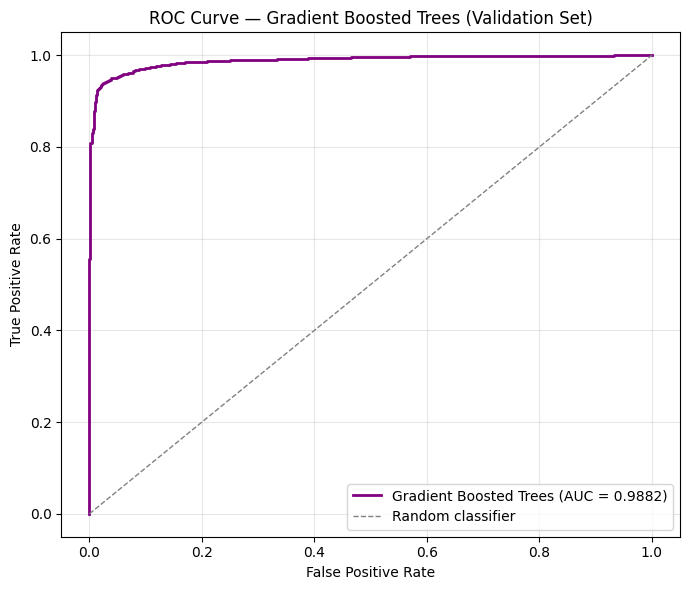

Saved figure to reports/figures/roc_gbt.png


In [20]:
#cell 7 Gradient Boosted Trees
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    maxIter=50,
    maxDepth=6,
    seed=42
)

pipeline_gbt = Pipeline(stages=[assembler_w2v, scaler, gbt])
model_gbt = pipeline_gbt.fit(train_df)
val_pred_gbt = model_gbt.transform(val_df)

auc_gbt = evaluator_auc.evaluate(val_pred_gbt)

print("Gradient Boosted Trees validation results:")
print(f"  Accuracy: {evaluator_acc.evaluate(val_pred_gbt):.4f}")
print(f"  F1:       {evaluator_f1.evaluate(val_pred_gbt):.4f}")
print(f"  ROC-AUC:  {auc_gbt:.4f}")

# Plot ROC curve
import matplotlib.pyplot as plt
import os
from sklearn.metrics import roc_curve

os.makedirs("../reports/figures", exist_ok=True)

probs_pdf = val_pred_gbt.select("label", "probability").toPandas()
y_true = probs_pdf["label"].values
y_score = probs_pdf["probability"].apply(lambda v: float(v[1])).values

fpr, tpr, _ = roc_curve(y_true, y_score)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="purple", linewidth=2, label=f"Gradient Boosted Trees (AUC = {auc_gbt:.4f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random classifier")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Gradient Boosted Trees (Validation Set)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/roc_gbt.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure to reports/figures/roc_gbt.png")

26/05/19 07:31:17 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
26/05/19 07:31:18 WARN DAGScheduler: Broadcasting large task binary with size 3.6 MiB


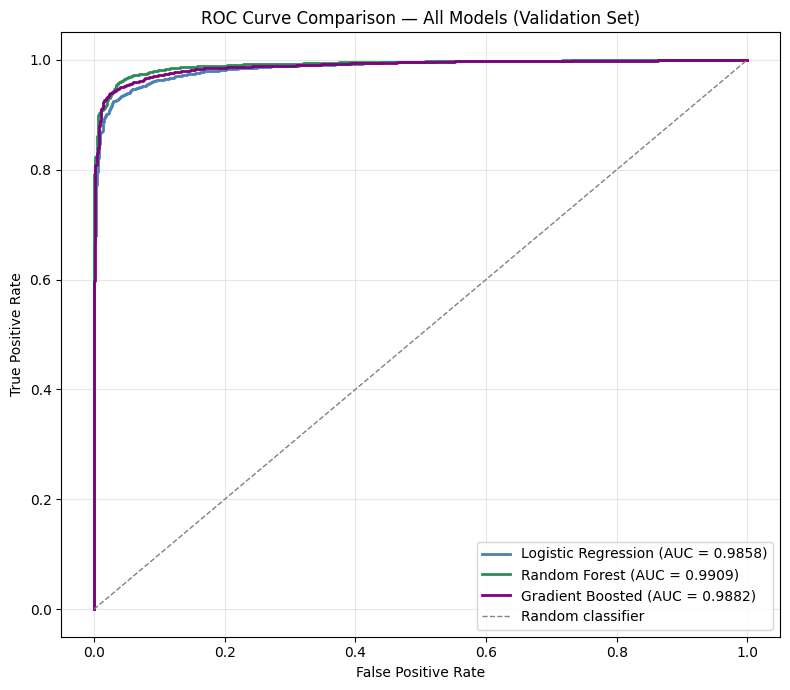

Saved figure to reports/figures/roc_comparison_all.png


In [21]:
# Combined ROC curves
import matplotlib.pyplot as plt
import os
from sklearn.metrics import roc_curve

os.makedirs("../reports/figures", exist_ok=True)


models_data = []
for name, preds, color in [
    ("Logistic Regression", val_pred_lr,  "steelblue"),
    ("Random Forest",       val_pred_rf,  "seagreen"),
    ("Gradient Boosted",    val_pred_gbt, "purple"),
]:
    auc = evaluator_auc.evaluate(preds)
    probs_pdf = preds.select("label", "probability").toPandas()
    y_true = probs_pdf["label"].values
    y_score = probs_pdf["probability"].apply(lambda v: float(v[1])).values
    fpr, tpr, _ = roc_curve(y_true, y_score)
    models_data.append((name, fpr, tpr, auc, color))


fig, ax = plt.subplots(figsize=(8, 7))
for name, fpr, tpr, auc, color in models_data:
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random classifier")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison — All Models (Validation Set)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/roc_comparison_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure to reports/figures/roc_comparison_all.png")

Confusion Matrices on Validation Set
Format: Rows = TRUE label, Columns = PREDICTED label

--- Logistic Regression ---
prediction   0.0   1.0
label                 
0           1030   182
1            128  4816
  True Negative  (human, labeled human): 1030
  False Positive (human, labeled AI):    182
  False Negative (AI, labeled human):    128
  True Positive  (AI, labeled AI):       4816
  AI recall:    0.9741
  Human recall: 0.8498



26/05/19 07:21:21 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
26/05/19 07:21:22 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


--- Random Forest ---
prediction   0.0   1.0
label                 
0           1077   135
1             87  4857
  True Negative  (human, labeled human): 1077
  False Positive (human, labeled AI):    135
  False Negative (AI, labeled human):    87
  True Positive  (AI, labeled AI):       4857
  AI recall:    0.9824
  Human recall: 0.8886

--- Gradient Boosted ---
prediction   0.0   1.0
label                 
0           1084   128
1            135  4809
  True Negative  (human, labeled human): 1084
  False Positive (human, labeled AI):    128
  False Negative (AI, labeled human):    135
  True Positive  (AI, labeled AI):       4809
  AI recall:    0.9727
  Human recall: 0.8944



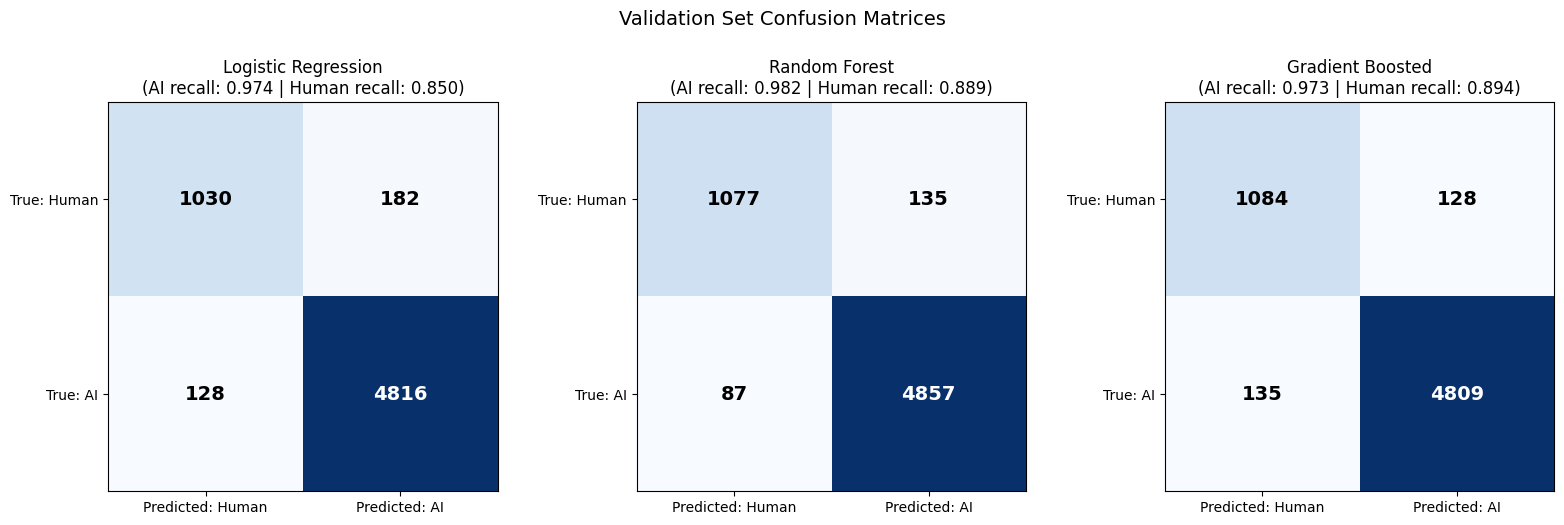

Saved figure to reports/figures/confusion_matrices_all.png


In [16]:
#cell 8 Confusion matrices
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("../reports/figures", exist_ok=True)

print("Confusion Matrices on Validation Set")
print("Format: Rows = TRUE label, Columns = PREDICTED label\n")

models_info = [
    ("Logistic Regression", val_pred_lr),
    ("Random Forest",       val_pred_rf),
    ("Gradient Boosted",    val_pred_gbt),
]

# Collect matrices and metrics for plotting
matrices = []

for name, preds in models_info:
    cm = (preds.groupBy("label", "prediction").count().toPandas()
              .pivot(index="label", columns="prediction", values="count")
              .fillna(0).astype(int))
    
    tn = cm.loc[0, 0.0] if 0.0 in cm.columns else 0
    fp = cm.loc[0, 1.0] if 1.0 in cm.columns else 0
    fn = cm.loc[1, 0.0] if 0.0 in cm.columns else 0
    tp = cm.loc[1, 1.0] if 1.0 in cm.columns else 0
    
    ai_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    human_recall = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    matrices.append({
        "name": name,
        "matrix": np.array([[tn, fp], [fn, tp]]),
        "ai_recall": ai_recall,
        "human_recall": human_recall,
    })
    
    # Print text version
    print(f"--- {name} ---")
    print(cm)
    print(f"  True Negative  (human, labeled human): {tn}")
    print(f"  False Positive (human, labeled AI):    {fp}")
    print(f"  False Negative (AI, labeled human):    {fn}")
    print(f"  True Positive  (AI, labeled AI):       {tp}")
    print(f"  AI recall:    {ai_recall:.4f}")
    print(f"  Human recall: {human_recall:.4f}")
    print()


# Visualize all three confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, info in zip(axes, matrices):
    cm = info["matrix"]
    im = ax.imshow(cm, cmap="Blues")
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Predicted: Human", "Predicted: AI"])
    ax.set_yticklabels(["True: Human", "True: AI"])
    ax.set_title(f"{info['name']}\n(AI recall: {info['ai_recall']:.3f} | Human recall: {info['human_recall']:.3f})")
    
    # Add count labels inside cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            ax.text(j, i, str(val), ha="center", va="center",
                    color="white" if val > cm.max()/2 else "black",
                    fontsize=14, fontweight="bold")

plt.suptitle("Validation Set Confusion Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrices_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure to reports/figures/confusion_matrices_all.png")

In [10]:
# Cell 9: Test set 
print(" FINAL EVALUATION on Test Set\n")

results = []
for name, model in [("Logistic Regression", model_lr),
                    ("Random Forest",       model_rf),
                    ("Gradient Boosted",    model_gbt)]:
    test_pred = model.transform(test_df)
    
    acc = evaluator_acc.evaluate(test_pred)
    f1 = evaluator_f1.evaluate(test_pred)
    auc = evaluator_auc.evaluate(test_pred)
    
    results.append({"Model": name, "Accuracy": acc, "F1": f1, "ROC-AUC": auc})
    print(f"{name:<22}  Acc: {acc:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}")

# Save 
results_df = pd.DataFrame(results)
results_df.to_csv("../reports/figures/test_set_results.csv", index=False)
print("\n Saved test results to reports/figures/test_set_results.csv")

 FINAL EVALUATION on Test Set

Logistic Regression     Acc: 0.9464  F1: 0.9458  AUC: 0.9845


26/05/19 07:15:31 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
26/05/19 07:15:31 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
26/05/19 07:15:32 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


Random Forest           Acc: 0.9553  F1: 0.9549  AUC: 0.9888
Gradient Boosted        Acc: 0.9484  F1: 0.9486  AUC: 0.9854

 Saved test results to reports/figures/test_set_results.csv


 Top 15 Feature Importances (Random Forest)

  w2v_2                  0.0910 ██████████████████
  w2v_75                 0.0758 ███████████████
  w2v_57                 0.0467 █████████
  f_diacritics           0.0459 █████████
  w2v_98                 0.0337 ██████
  w2v_74                 0.0326 ██████
  w2v_78                 0.0307 ██████
  w2v_45                 0.0306 ██████
  w2v_46                 0.0288 █████
  w2v_36                 0.0276 █████
  w2v_15                 0.0259 █████
  w2v_42                 0.0229 ████
  w2v_7                  0.0216 ████
  w2v_87                 0.0207 ████
  w2v_77                 0.0202 ████


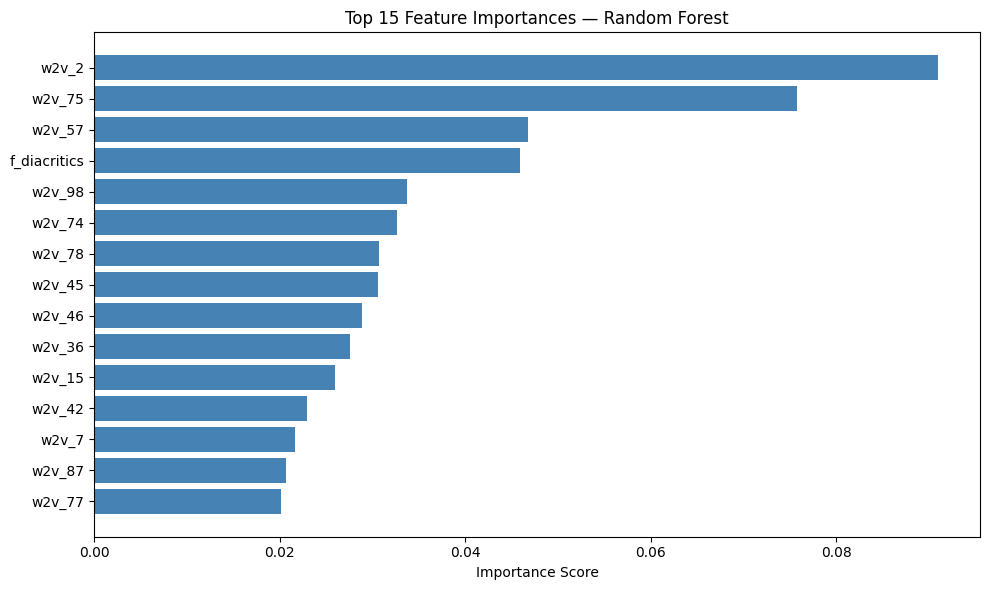


 Saved chart to reports/figures/feature_importance_rf.png


In [17]:
# Cell 10: Feature importance from Random Forest


import numpy as np
import matplotlib.pyplot as plt

rf_stage = model_rf.stages[-1]  
importances = rf_stage.featureImportances.toArray()


feature_names = STYLO_COLS + [f"w2v_{i}" for i in range(100)]


top_idx = np.argsort(importances)[-15:][::-1]
top_names = [feature_names[i] for i in top_idx]
top_vals = [importances[i] for i in top_idx]


print(" Top 15 Feature Importances (Random Forest)\n")
for n, v in zip(top_names, top_vals):
    bar = "█" * int(v * 200)
    print(f"  {n:<22} {v:.4f} {bar}")


fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top_vals)), top_vals[::-1], color="steelblue")
ax.set_yticks(range(len(top_vals)))
ax.set_yticklabels(top_names[::-1])
ax.set_xlabel("Importance Score")
ax.set_title("Top 15 Feature Importances — Random Forest")
plt.tight_layout()
plt.savefig("../reports/figures/feature_importance_rf.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n Saved chart to reports/figures/feature_importance_rf.png")

In [12]:
# Cell 11: Save the BEST model 
import os

best_model = model_rf  
model_save_path = "file://" + os.path.abspath("../models/best_model_rf")

best_model.write().overwrite().save(model_save_path)
print(f" Best model saved to: {model_save_path}")

 Best model saved to: file:///home/hadoop/arabic-ai-detection/models/best_model_rf


In [13]:
# Cell 12:  results table 
print("=" * 75)
print(" RESULTS ")
print("=" * 75)


all_results = []
for name, val_pred, model in [
    ("Logistic Regression", val_pred_lr, model_lr),
    ("Random Forest",       val_pred_rf, model_rf),
    ("Gradient Boosted",    val_pred_gbt, model_gbt),
]:
    test_pred = model.transform(test_df)
    all_results.append({
        "Model": name,
        "Val Accuracy": f"{evaluator_acc.evaluate(val_pred):.4f}",
        "Val F1":       f"{evaluator_f1.evaluate(val_pred):.4f}",
        "Val AUC":      f"{evaluator_auc.evaluate(val_pred):.4f}",
        "Test Accuracy": f"{evaluator_acc.evaluate(test_pred):.4f}",
        "Test F1":       f"{evaluator_f1.evaluate(test_pred):.4f}",
        "Test AUC":      f"{evaluator_auc.evaluate(test_pred):.4f}",
    })

summary_df = pd.DataFrame(all_results)
print("\n" + summary_df.to_string(index=False))
summary_df.to_csv("../reports/figures/model_comparison.csv", index=False)
print("\n Saved to reports/figures/model_comparison.csv")

 PHASE 3 RESULTS 


26/05/19 07:15:38 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
26/05/19 07:15:38 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
26/05/19 07:15:39 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
26/05/19 07:15:40 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
26/05/19 07:15:40 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
26/05/19 07:15:40 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB



              Model Val Accuracy Val F1 Val AUC Test Accuracy Test F1 Test AUC
Logistic Regression       0.9496 0.9492  0.9858        0.9464  0.9458   0.9845
      Random Forest       0.9639 0.9637  0.9909        0.9553  0.9549   0.9888
   Gradient Boosted       0.9573 0.9573  0.9882        0.9484  0.9486   0.9854

 Saved to reports/figures/model_comparison.csv
